<details>
  <summary><strong>MIT License（クリックで展開）</strong></summary>

  <pre>
MIT License
Copyright (c) 2023-2025 AI Course Notebook Contributors
Repository: https://github.com/arch-inform-kaken-group/ai-course-notebooks

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
  </pre>
</details>

# オートエンコーダによる くずし字 の再構成・生成

今回のハンズオンでは，生成モデルの代表例であるオートエンコーダを体感していただくことが目標です．


## 目的：10種類のくずし字（草書体）を再構成・生成すること


[人文学オープンデータ共同利用センター（Center for Open Data in the Humanities / CODH）](http://codh.rois.ac.jp/)より提供されている，[日本古典籍くずし字データセット](http://codh.rois.ac.jp/char-shape/)は，日本の古典文学のデジタルアーカイブ化とその利用を促進する目的で作成されました．特に，歴史的な書物のデジタル化に伴い，くずし字の認識は重要な課題の1つとなっております．

<br>

このデータセットの中でも，[Kuzushiji-MNISTデータセット（機械学習用くずし字データセット）](http://codh.rois.ac.jp/kmnist/)は，機械学習の練習用にしばしば利用されるMNIST手書き数字データセットを踏襲した形式で整備されています．
これにより，若干の設定変更だけで気軽に Kuzushiji-MNIST を試すことができます．

<br>

Kuzushiji-MNISTデータセットでは，以下の3つのデータセットが整備されていますが，
今回は 1. Kuzushiji-MNIST（平仮名10種類）を使用します．

1. Kuzushiji-MNIST（平仮名10種類）
2. Kuzushiji-49（平仮名49種類，不均衡データ）
3. Kuzushiji-Kanji（3832種類の漢字，不均衡データ）

<br>

Kuzushiji-MNISTの内容は以下となります：
- **画像数**：訓練用画像：70000枚，テスト用画像：10000枚
- **クラス**：10種類の平仮名（お，き，す，つ，な，は，ま，や，れ，を）
- **画像形式**：各画像は 28 × 28 px のグレイスケール画像



<hr>

Kuzushiji-MNIST データセット出典：<br>

［人文学オープンデータ共同利用センター（CODH）］http://codh.rois.ac.jp/kmnist/


［arXiv］[Clanuwat, T., Bober-Irizar, M., Kitamoto, A., Lamb, A., Yamamoto, K. & Ha, D.  Deep Learning for Classical Japanese Literature. 3 Dec 2018, arXiv:1812.01718](https://arxiv.org/abs/1812.01718)

［GitHub］https://github.com/rois-codh/kmnist

Kuzushiji-MNISTデータセットのサンプル画像（左）：

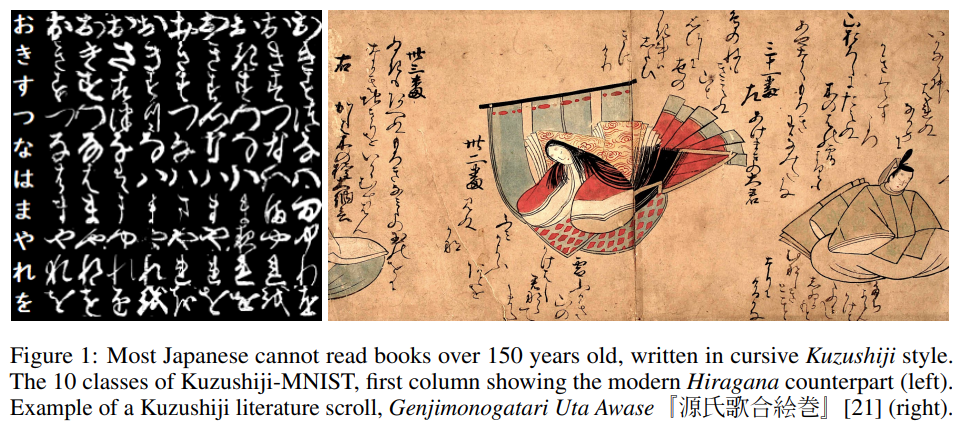

<small>Deep Learning for Classical Japanese Literature (Jun. 11, 2024, 09:30 UTC). In arXiv:The Open Access Eprint Archive. Retrieved from https://arxiv.org/pdf/1812.01718 </small>

## GPU の利用確認とTensorFlowのバージョン確認

In [1]:
!nvidia-smi

Mon Jun  1 04:16:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import tensorflow as tf
import os

!pip install -q japanize_matplotlib

print('TensorFlow version:',tf.__version__)

restart_flag = False

if tf.__version__ != '2.20.0':
    !pip install -q --upgrade tensorflow==2.20.0
    print('TensorFlow version:',tf.__version__)
    restart_flag = True


# 以下は，ライブラリのバージョンが変更された場合のみ実行されます．
if restart_flag :
    print("ライブラリバージョンを変更した場合に，自動でランタイムを再起動します．")
    print("colabの場合は【不明な理由でクラッシュした】旨の警告が左下に出てきますが，")
    print("これは無視しても問題ないので次以降のコードセルを実行してください．")
    # ランタイムを再起動させるために，わざとクラッシュさせています．
    get_ipython().kernel.do_shutdown(restart=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 70.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
TensorFlow version: 2.20.0


## ライブラリのインポート

In [3]:
import os # os：標準ライブラリ，OS依存の処理（環境変数やフォルダ作成など）を扱う
import datetime # datetime：標準ライブラリ，日付関連データを扱う
import random # random：標準ライブラリ，擬似乱数発生器
import numpy as np # numpy：数値計算用ライブラリの一つ
import pandas as pd # pandas：表計算用ライブラリの一つ
from IPython.display import display # Colabなどで一部のデータをprint()よりも綺麗に出力できる関数
import matplotlib.pylab as plt # matplotlib：グラフ描画用ライブラリの一つ
import japanize_matplotlib
import seaborn as sns # seaborn：グラフ描画用ライブラリの一つ
import plotly.express as px # plotly：グラフ描画用ライブラリの一つ
import scipy # scipy：数値計算・統計解析用ライブラリの一つ
# tensorboard：深層学習ライブラリTensorFlowのダッシュボード出力用設定
%load_ext tensorboard
import tensorflow as tf # TensorFlow：深層学習ライブラリ一つ

### 擬似乱数発生器のrandom seed 固定

* 下記プログラム中で生成・使用される擬似乱数列を固定します．
* random seed は擬似乱数列を生成する時の初期化に使われる数値です．
* 明示的に指定しない場合は，時刻などで初期化されます．
* 今回は再現性を確保する（誰がいつ実行しても同じ擬似乱数列を生成させる）ために random seed を固定します．

<small> ※ colab では割り当てられるCPU/GPUやライブラリバージョンの違いにより，完全再現は難しい場合もあります.</small>

In [4]:
def set_seed(seed=123):
    # hash seed の固定
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Python外部ライブラリ：TensorFlow の ニューラルネットワークを決定論的に動作させる
    os.environ['TF_DETERMINISTIC_OPS'] = 'true'
    # Python外部ライブラリ：TensorFlow の ニューラルネットワークを決定論的に動作させる
    os.environ['TF_CUDNN_DETERMINISTIC'] = 'true'
    # Python標準ライブラリ：random の seed固定
    random.seed(seed)
    # Python外部ライブラリ：Numpy の seed固定
    np.random.seed(seed)
    # Python外部ライブラリ：TensorFlow の seed固定
    tf.random.set_seed(seed)

set_seed(123)

## データセットの取得



In [5]:
# 本家のWebサイトではなく，tensorflow-datasetsライブラリから
# 利用できるようになっている KMNIST データセット を読み込みます．
# https://www.tensorflow.org/datasets/catalog/kmnist

!pip install -q tensorflow-datasets

import tensorflow_datasets as tfds

train_dataset, test_dataset = tfds.load(name="kmnist", split=["train","test"])


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/kmnist/incomplete.DRF0RG_3.0.1/kmnist-train.tfrecord-[0-9][0-9][0-9][0-9][…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/kmnist/incomplete.DRF0RG_3.0.1/kmnist-test.tfrecord-[0-9][0-9][0-9][0-9][0…

Dataset kmnist downloaded and prepared to /root/tensorflow_datasets/kmnist/3.0.1. Subsequent calls will reuse this data.


### データセットの中身を可視化（一部）


このデータセットは MNIST手書き数字データセット の形式を踏襲しているため，
正解ラベルは 0 ～ 9 の数字ラベルとして格納されています．

数字ラベル正解ラベルのくずし字（平仮名）の対応表：

|数字ラベル|くずし字（平仮名）|
|---:|:---:|
|0| お |
|1| き |
|2| す |
|3| つ |
|4| な |
|5| は |
|6| ま |
|7| や |
|8| れ |
|9| を |

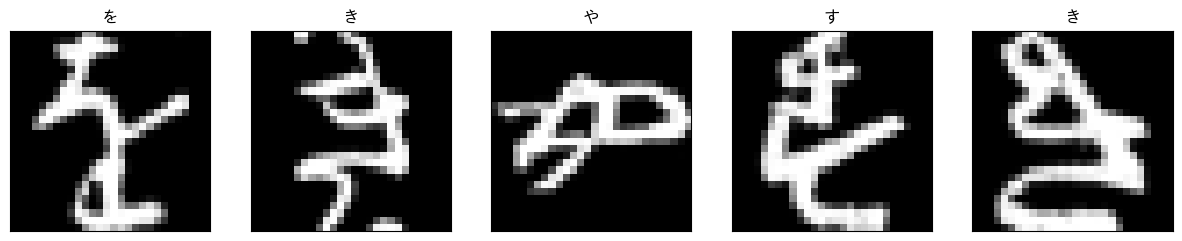

In [6]:
# データセットの中身を5つ可視化する
label_num_to_label_name = {0:'お',1:'き',2:'す',3:'つ',4:'な',5:'は',6:'ま',7:'や',8:'れ',9:'を'}

fig = plt.figure(figsize=(15,3))
i = 0
for data in train_dataset.batch(1).take(5):
    ax = fig.add_subplot(1, 5, i+1, xticks=[], yticks=[])
    ax.imshow(data["image"][0], cmap='gray')
    ax.set_title(label_num_to_label_name[data["label"].numpy()[0]], fontsize=12)
    i += 1
plt.show()

### データの前処理

次のセルでは，以下の処理を行います．
1.   画像データと正解ラベルデータの分離
2.   画像データを1次元ベクトルへ変換

<br>

今回のハンズオンでは， **正解ラベル（label）の情報をモデルへ入力しません**．

[tensorflow datasetsから提供されるKMNISTデータセット](https://www.tensorflow.org/datasets/catalog/kmnist) は，画像データと正解ラベルデータが組となった [tf.data.Dataset形式](https://www.tensorflow.org/api_docs/python/tf/data/Dataset)です．

今回のハンズオンでは， 正解ラベルの情報をモデルへ入力しないことを明示するため，画像データと正解ラベルデータを**分離**します．

<br>

また，今回のモデルでは畳み込み層を使用せず，そのまま全結合層へ入力します．

そのため，2次元の画像データを1次元ベクトルへ変換（平坦化）します．


In [7]:
# バッチサイズの決定
batch_size = 128


# 画像データと正解ラベルデータを分離する
train_images, train_labels = [], []
for batch in tfds.as_numpy(train_dataset.batch(batch_size)):
    t_images, t_labels = batch["image"], batch["label"]
    train_images.extend(t_images)
    train_labels.extend(t_labels)
train_images, train_labels = np.array(train_images), np.array(train_labels)

test_images, test_labels = [], []
for batch in tfds.as_numpy(test_dataset.batch(batch_size)):
    t_images, t_labels = batch["image"], batch["label"]
    test_images.extend(t_images)
    test_labels.extend(t_labels)
test_images, test_labels = np.array(test_images), np.array(test_labels)


# 画像データの各ピクセルの値を0-1の範囲に収める(正規化)
train_images = train_images / 255
test_images = test_images / 255


print("1次元ベクトル変換 前 の画像データ形状：")
print(train_images.shape)
print(test_images.shape)


# 画像を 1次元ベクトル へ変換する
train_images = train_images.reshape(train_images.shape[0], -1)
test_images = test_images.reshape(test_images.shape[0], -1)

print("1次元ベクトル変換 後 の画像データ形状：")
print(train_images.shape)
print(test_images.shape)


1次元ベクトル変換 前 の画像データ形状：
(60000, 28, 28, 1)
(10000, 28, 28, 1)
1次元ベクトル変換 後 の画像データ形状：
(60000, 784)
(10000, 784)


# AEによるKMNISTの画像再構成

AE（Auto Encoder）は，エンコーダで元の画像を低次元の特徴量（潜在変数）へ圧縮し，デコーダで潜在変数から元の画像を復元させるようなネットワークです．

このモデルは，異常検知やクラスタリングなどの用途で使用されます．



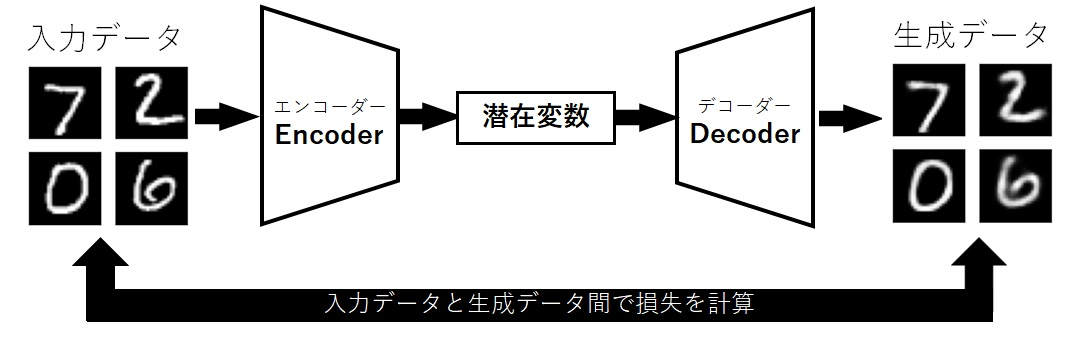

#### AEの損失関数

本ハンズオンの損失関数では，reconstruction loss（再構成損失）を採用します．入力画像に対し，生成画像が正確に復元できたかの度合いを表します．今回は cross entropy error （交差エントロピー誤差）とします．

分類問題のようにカテゴリ（種別，分類問題における正解ラベル） の一致度を評価しているのではなく，**平坦化した入力画像のベクトルと生成画像（復元画像）のベクトルの一致度を評価していることに注意してください．**

$$
\text{reconstruction loss} = \frac{1}{N}\sum^{N}_{i=1} \sum^{M}_{j=1}\{{-x_{ij}\log({y_{ij}})-(1-x_{ij})\log(1-y_{ij})}\}
$$

* $M$は，1枚の画像を平坦化した1次元ベクトルの要素数
 - 今回は，28ピクセル×28ピクセル = 784個
* $N$は，バッチサイズ
 - 今回は batch_size = 128，つまり128枚単位でデータを処理している
* $x_{ij}$は，各バッチにおける入力データの各要素
* $y_{ij}$は，各バッチにおける生成データの各要素



## AEモデルの構築

In [8]:
# AEのモデル構築
input_dim = train_images.shape[1]
output_dim = train_images.shape[1]

x = tf.keras.Input(shape = [input_dim])

# エンコーダの定義
#（encoder1_layerを後で特徴抽出器として使用する）
encoder1_layer = tf.keras.layers.Dense(units = 512, activation = 'relu')
encoder1 = encoder1_layer(x)
#（encoder2_layerを後で特徴抽出器として使用する）
encoder2_layer = tf.keras.layers.Dense(units = 64, activation = 'relu')
encoder2 = encoder2_layer(encoder1)
#（encoder3_layerを後で特徴抽出器として使用する）
encoder3_layer = tf.keras.layers.Dense(units = 32, activation = 'relu')
encoder3 = encoder3_layer(encoder2)
#（encoder4_layerを後で特徴抽出器として使用する）
encoder4_layer = tf.keras.layers.Dense(units = 2, activation = 'linear')
encoder4 = encoder4_layer(encoder3)

# デコーダの定義
decoder1 = tf.keras.layers.Dense(units = 32, activation = 'relu')(encoder4)
decoder2 = tf.keras.layers.Dense(units = 64, activation = 'relu')(decoder1)
decoder3 = tf.keras.layers.Dense(units = 512, activation = 'relu')(decoder2)
decoder4 = tf.keras.layers.Dense(units = output_dim, activation = 'sigmoid')(decoder3)
y = decoder4


# 損失関数の定義
class ReconstructionLossLayer(tf.keras.layers.Layer):
    def __init__(self, batch_size, **kwargs):
        super().__init__(**kwargs)
        self.batch_size = batch_size

    def call(self, inputs):
        x, y = inputs

        # reconstruction loss（再構成損失）
        # 1.0e-6; ゼロ割による無限大エラーを防ぐために非常に小さな数を加算している
        loss = tf.keras.ops.sum(
            - x * tf.keras.ops.log(y + 1e-6)
            - (1 - x) * tf.keras.ops.log(1 - y + 1e-6),
            axis=None
        ) / self.batch_size

        self.add_loss(loss)
        return y

y = ReconstructionLossLayer(batch_size, name="reconstruction_loss")([x, y])

# AutoEncoderモデルの定義
model_ae = tf.keras.Model(inputs = x, outputs = y, name = 'model_ae')
model_ae.compile(optimizer="Adam")

model_ae.summary()

Model: "model_ae"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    401,920 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     32,832 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 2)         │         66 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │         96 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      2,112 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 512)       │     33,280 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 784)       │    402,192 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reconstruction_loss │ (None, 784)       │          0 │ input_layer[0][0… │
│ (ReconstructionLos… │                   │            │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 874,578 (3.34 MB)

 Trainable params: 874,578 (3.34 MB)

 Non-trainable params: 0 (0.00 B)

### 未訓練状態におけるモデルの出力を確認する

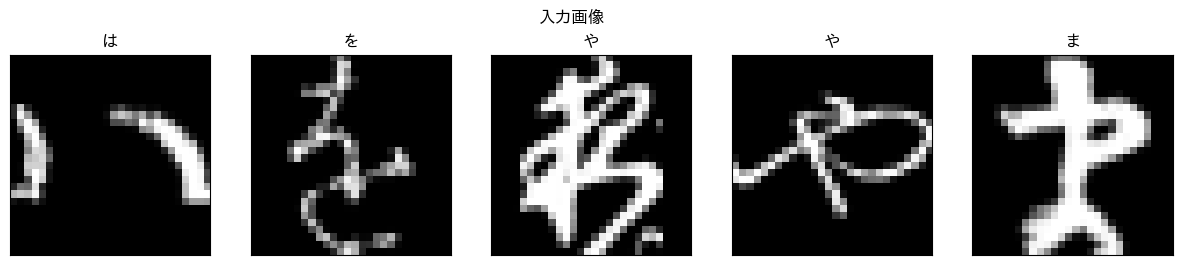

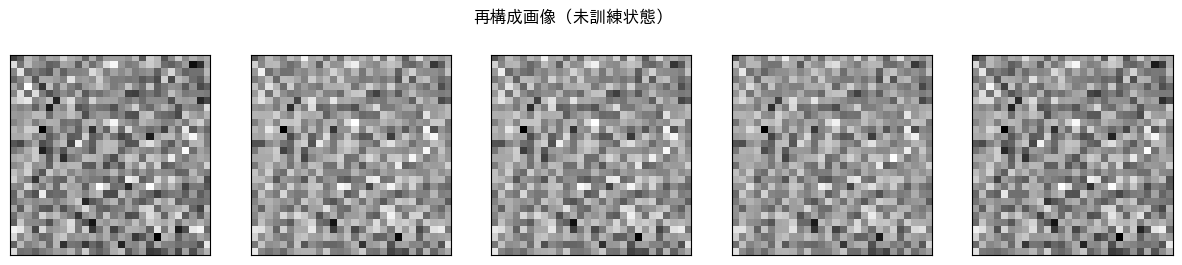

In [9]:

fig = plt.figure(figsize=(15,3))
for i in range(5):
    ax = fig.add_subplot(1, 5, i+1, xticks=[], yticks=[])
    ax.imshow(tf.reshape(test_images[i,:], (28,28) ), cmap='gray')
    ax.set_title(label_num_to_label_name[test_labels[i]], fontsize=12)
plt.suptitle("入力画像", fontsize=12)
plt.show()

fig = plt.figure(figsize=(15,3))
generate_images = model_ae(test_images[:5,:])
for i in range(5):
    ax = fig.add_subplot(1, 5, i+1, xticks=[], yticks=[])
    ax.imshow(tf.reshape(generate_images[i,:], (28,28) ), cmap='gray')
plt.suptitle("再構成画像（未訓練状態）", fontsize=12)
plt.show()


## モデルの訓練

Epoch 1/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 332.7965

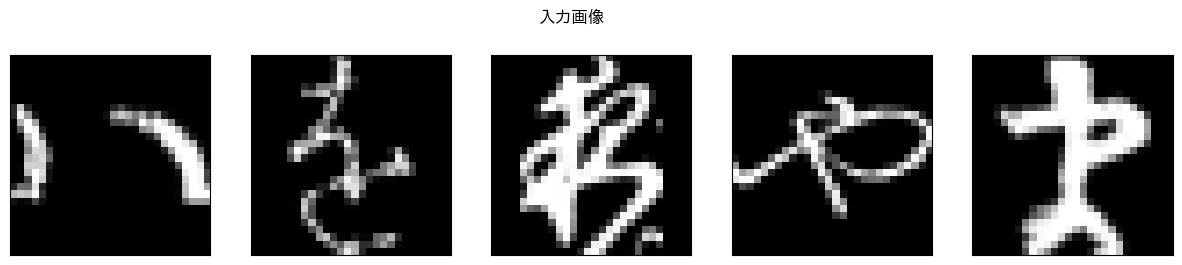

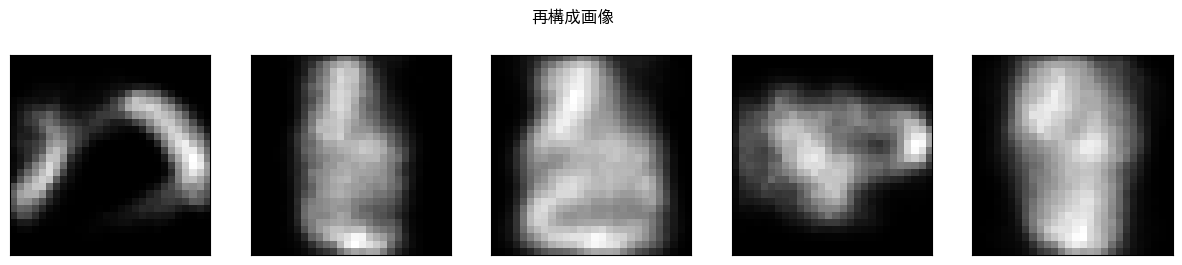

469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 301.0309 - val_loss: 282.1172
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 272.9874 - val_loss: 276.3499
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 266.4058 - val_loss: 273.3964
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 262.2994 - val_loss: 270.8374
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 259.3368 - val_loss: 268.9113
Epoch 6/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 258.4747

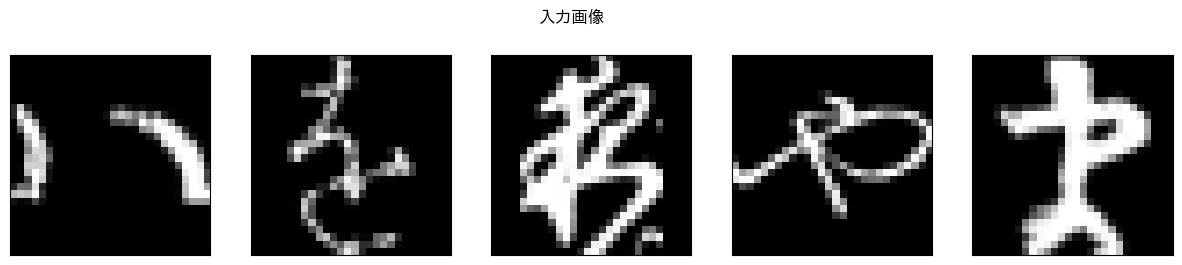

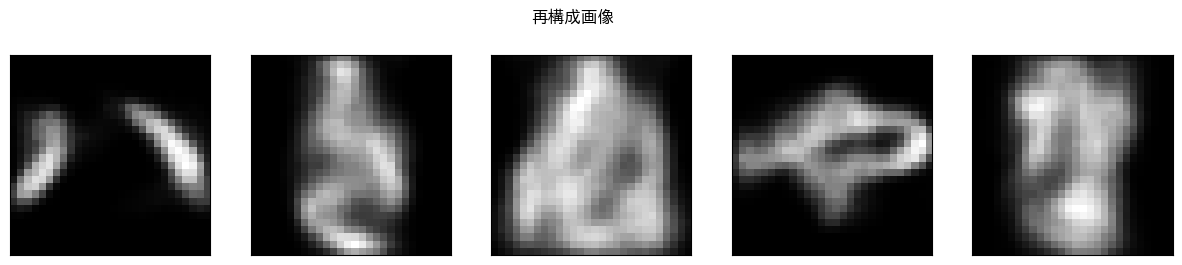

469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 256.9887 - val_loss: 268.1227
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 255.2150 - val_loss: 266.7907
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 253.6477 - val_loss: 266.0791
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 252.1674 - val_loss: 265.3323
Epoch 10/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 251.1195 - val_loss: 264.9463
Epoch 11/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 251.2791

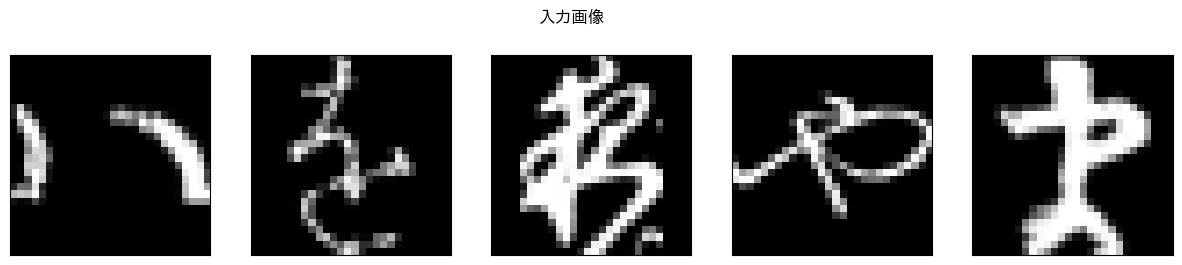

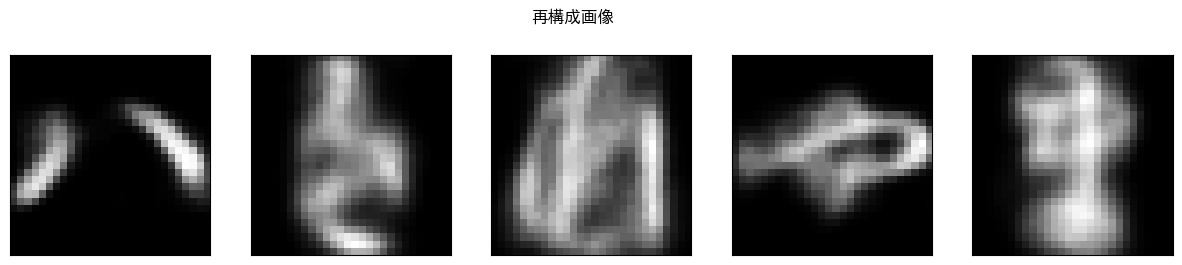

469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 250.0670 - val_loss: 265.0910
Epoch 12/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 249.3820 - val_loss: 263.8945
Epoch 13/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 248.2500 - val_loss: 264.1039
Epoch 14/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 247.4509 - val_loss: 262.5805
Epoch 15/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 246.4958 - val_loss: 262.8250
Epoch 16/30
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 247.1397

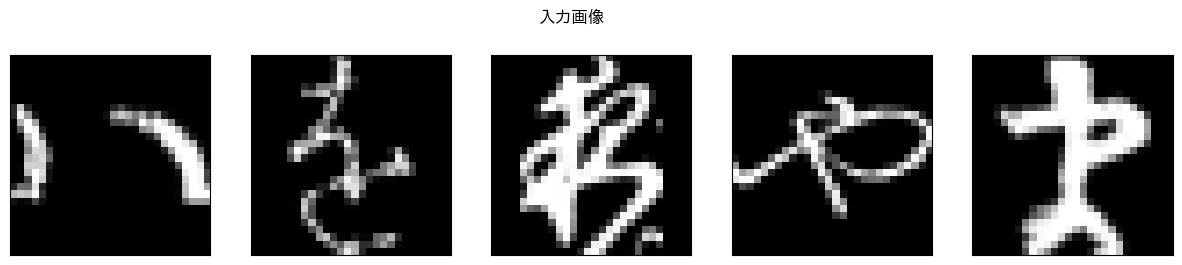

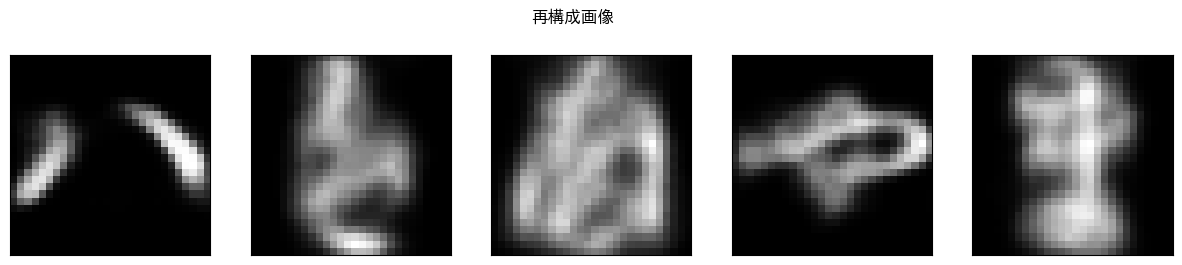

469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 246.0646 - val_loss: 262.0721
Epoch 17/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 245.3653 - val_loss: 262.2747
Epoch 18/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 244.9644 - val_loss: 261.6909
Epoch 19/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 244.1868 - val_loss: 262.4282
Epoch 20/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 243.9162 - val_loss: 261.3840
Epoch 21/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 244.2472

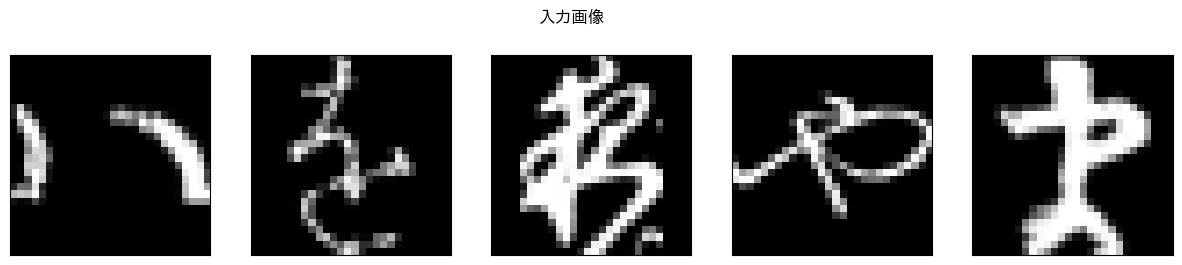

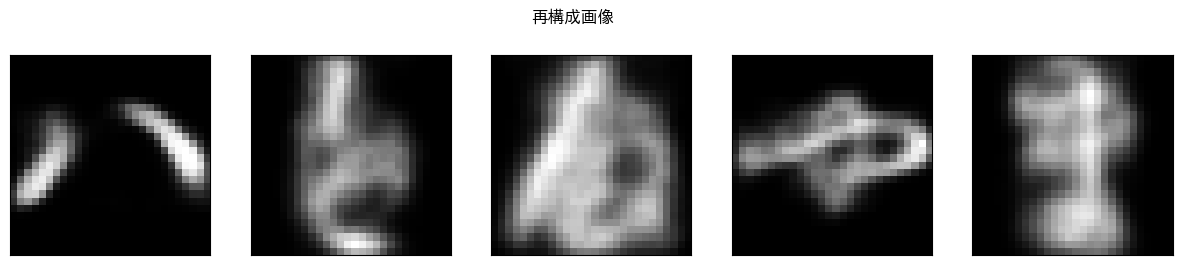

469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 243.0381 - val_loss: 260.7859
Epoch 22/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 242.5633 - val_loss: 260.1328
Epoch 23/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 241.8440 - val_loss: 260.8141
Epoch 24/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 241.3420 - val_loss: 260.2295
Epoch 25/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 241.2616 - val_loss: 260.0922
Epoch 26/30
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 241.9589

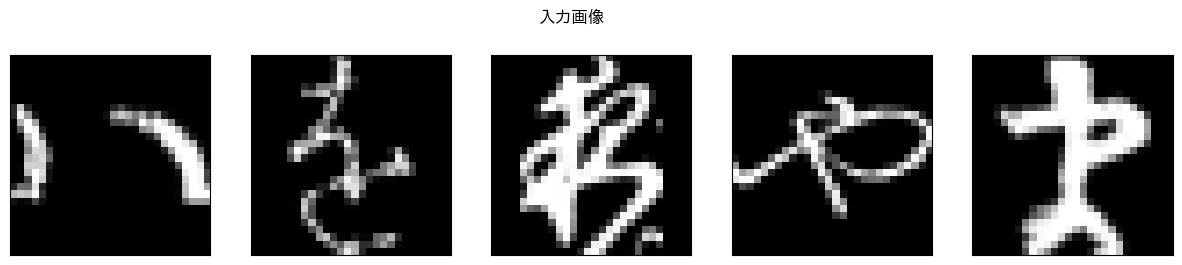

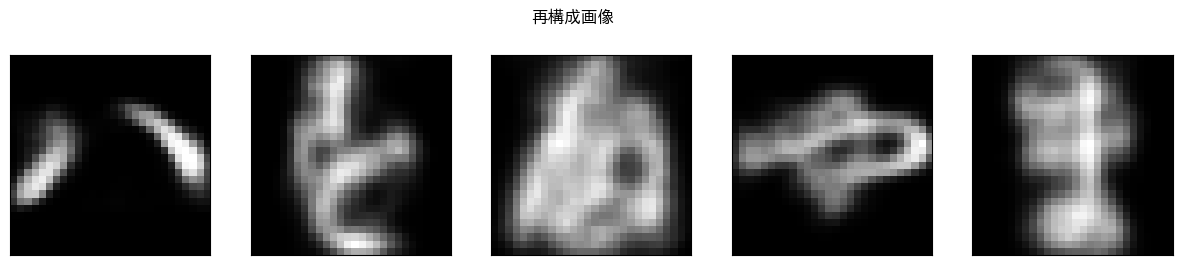

469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 240.8172 - val_loss: 259.6674
Epoch 27/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 240.2999 - val_loss: 259.5031
Epoch 28/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 239.9980 - val_loss: 259.7097
Epoch 29/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 239.6760 - val_loss: 259.5474
Epoch 30/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 239.2114 - val_loss: 259.0268


In [10]:
# 実行時間 約2～3分

class DisplayCallback(tf.keras.callbacks.Callback):

    def __init__(self, test_images):
        super().__init__()
        self.test_images = test_images

    def on_epoch_end(self, epoch, logs):
        # 5 Epoch毎に推論画像を出力する
        if (epoch % 5 == 0) :
            fig = plt.figure(figsize=(15,3))
            for i in range(5):
                ax = fig.add_subplot(1, 5, i+1, xticks=[], yticks=[])
                ax.imshow(tf.reshape(self.test_images[i,:], (28,28) ), cmap='gray')
            plt.suptitle("入力画像", fontsize=12)
            plt.show()
            fig = plt.figure(figsize=(15,3))
            generate_images = model_ae(self.test_images[:5,:])
            for i in range(5):
                ax = fig.add_subplot(1, 5, i+1, xticks=[], yticks=[])
                ax.imshow(tf.reshape(generate_images[i,:], (28,28) ), cmap='gray')
            plt.suptitle("再構成画像", fontsize=12)
            plt.show()


# 訓練中のログファイルを作成する準備
callbacks = []
callbacks.append(tf.keras.callbacks.CSVLogger('ae_training_log.csv'))
callbacks.append(DisplayCallback(test_images))

history = model_ae.fit(x = train_images,
                       # 正解ラベルの情報はモデルへ入れない
                        y = None,
                        shuffle = True,
                        epochs = 30,
                        batch_size = batch_size,
                        verbose = 1,
                       # 正解ラベルの情報はモデルへ入れない
                        validation_data=(test_images, None),
                        callbacks = callbacks
                        )

### 再構成損失の推移

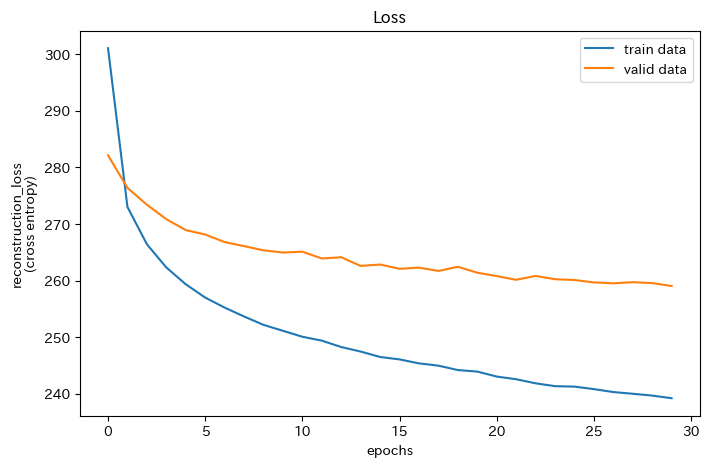

In [11]:
log_df = pd.read_csv('ae_training_log.csv')

epochs = log_df["epoch"].values
train_loss = log_df["loss"].values
valid_loss = log_df["val_loss"].values

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(epochs, train_loss, label="train data")
ax.plot(epochs, valid_loss, label="valid data")
ax.set_xlabel("epochs")
ax.set_ylabel("reconstruction_loss\n(cross entropy)")
ax.legend(loc="upper right")
ax.set_title("Loss")

plt.show()

## 元画像と復元画像の比較

テスト用データの画像を入力として，AEで再構成した画像と比較します．

まずはテスト用データの画像を描画します．

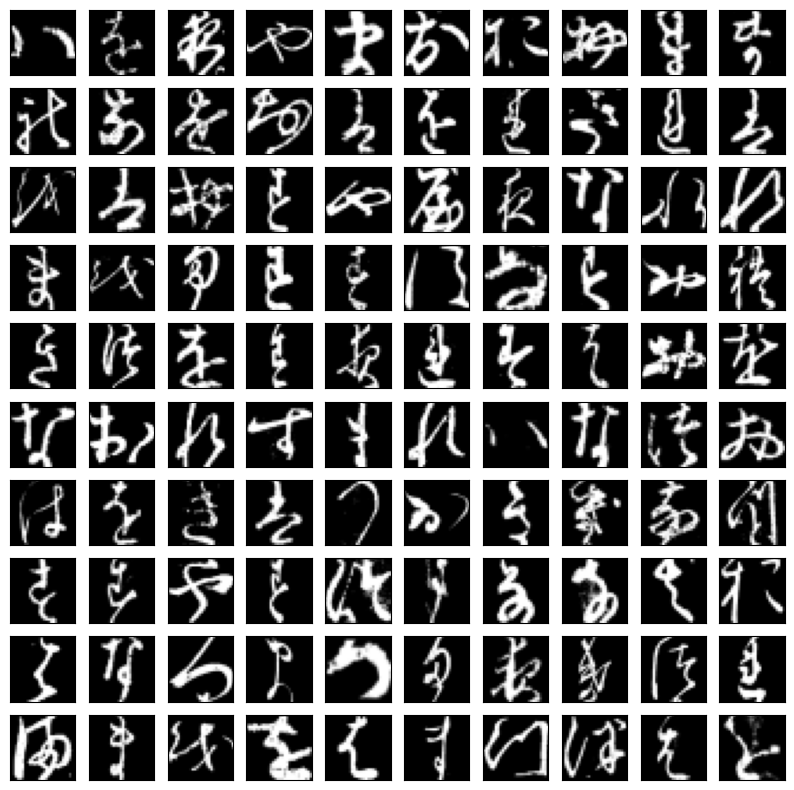

In [12]:
# モデルへ入力したのKMNISTの画像を描画する．
fig = plt.figure(figsize=(10, 10))
for i in range(100):

    x = test_images[i].reshape(28,28)
    ax = fig.add_subplot(10, 10, i+1, xticks=[], yticks=[])
    ax.imshow(x, 'gray')

次に，AEで再構成した画像を描画します．

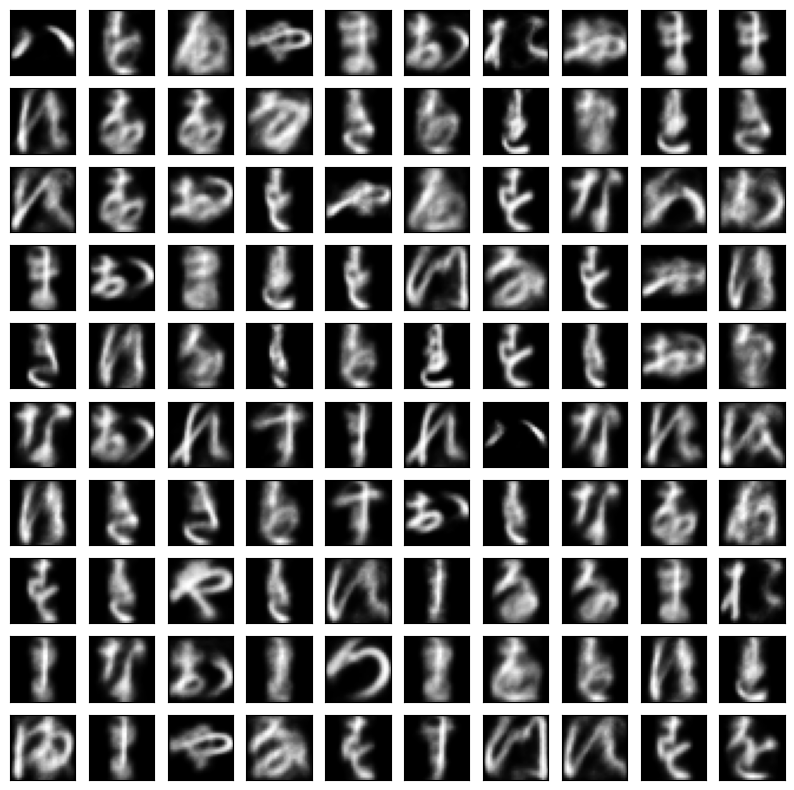

In [13]:
# AEモデルで再構成したKMNIST画像を描画する．
fig = plt.figure(figsize=(10, 10))

for i in range(100):
    x= test_images[i]
    x = tf.reshape(x,(-1,28*28))
    y = model_ae(x)
    im = tf.reshape(y,(28,28))
    ax = fig.add_subplot(10, 10, i+1, xticks=[], yticks=[])
    ax.imshow(im, 'gray')

## エンコーダを特徴抽出器として利用する

画像データを特徴抽出器へ入力し，取得した潜在変数を散布図で描画します．

まずは訓練データから見てみましょう．



In [14]:
# 実行時間15～30秒

# 特徴抽出器を定義する
input_encoder = tf.keras.layers.Input(shape = [input_dim])
h_encoder = encoder1_layer(input_encoder)
h_encoder = encoder2_layer(h_encoder)
h_encoder = encoder3_layer(h_encoder)
latent_variable = encoder4_layer(h_encoder)
feature_extractor = tf.keras.Model(input_encoder, latent_variable)

# 訓練データを特徴抽出器へ入力し，潜在変数を取得する
train_feature_data = feature_extractor.predict(train_images, verbose=0)


# 取得した訓練データの潜在変数を散布図で描画する．
df = pd.DataFrame({
    "z_0": train_feature_data[:, 0], "z_1": train_feature_data[:, 1],
    "number_label": train_labels,
    "label": [label_num_to_label_name[t_label] for t_label in train_labels]
})
fig = px.scatter(
    df, x="z_0", y="z_1",
    color="label", symbol="label",
    hover_data={
        "z_0": True,"z_1": True,
        "label": True,"train_data_index": df.index
    },
    category_orders={"label": list(label_num_to_label_name.values())},
    title="AEモデルで取得された Kuzushiji-MNIST 訓練データ（N=60000）の潜在変数 散布図"
)
fig.update_layout(
    legend_title_font_size=20,
    legend_font_size=18,
    title_font_size=24,
    width=1400,
    height=1000
)
fig.show()

!mkdir -p plots
fig.write_html("./plots/2026_12_AE-traindata_ja.html", include_plotlyjs=True, full_html=True, auto_open=False)

<div class="sphinx-only" style="display:none">
  <iframe
    src="../_static/plotly/2026_12_AE-traindata_ja.html"
    width="100%"
    height="760"
    style="border:0;"
  ></iframe>
</div>

グラフが表示されない場合：[GitHub上のPNGファイルを開く](https://github.com/arch-inform-kaken-group/ai-course-notebooks/tree/main/notebooks/ja_2026/plots/2026_12_AE-traindata.png)

次に，テストデータも見てみましょう．


In [15]:
# 特徴抽出器を定義する（前セルと同じ）
#input_encoder = tf.keras.layers.Input(shape = input_dim)
#h_encoder = encoder1_layer(input_encoder)
#h_encoder = encoder2_layer(h_encoder)
#h_encoder = encoder3_layer(h_encoder)
#latent_variable = encoder4_layer(h_encoder)
#feature_extractor = tf.keras.Model(input_encoder, latent_variable)


# テストデータを特徴抽出器へ入力し，潜在変数を取得する
test_feature_data = feature_extractor.predict(test_images, verbose=0)

# 取得したテストデータの潜在変数を散布図で描画する．
df = pd.DataFrame({
    "z_0": test_feature_data[:, 0], "z_1": test_feature_data[:, 1],
    "number_label": test_labels,
    "label": [label_num_to_label_name[t_label] for t_label in test_labels]
})
fig = px.scatter(
    df, x="z_0", y="z_1",
    color="label", symbol="label",
    hover_data={
        "z_0": True,"z_1": True,
        "label": True,"test_data_index": df.index
    },
    category_orders={"label": list(label_num_to_label_name.values())},
    title="AEモデルで取得された Kuzushiji-MNIST テストデータ（N=10000）の潜在変数 散布図"
)
fig.update_layout(
    legend_title_font_size=20,
    legend_font_size=18,
    title_font_size=24,
    width=1400,
    height=1000
)
fig.show()

!mkdir -p plots
fig.write_html("./plots/2026_12_AE-testdata_ja.html", include_plotlyjs=True, full_html=True, auto_open=False)

<div class="sphinx-only" style="display:none">
  <iframe
    src="../_static/plotly/2026_12_AE-testdata_ja.html"
    width="100%"
    height="760"
    style="border:0;"
  ></iframe>
</div>

グラフが表示されない場合：[GitHub上のPNGファイルを開く](https://github.com/arch-inform-kaken-group/ai-course-notebooks/tree/main/notebooks/ja_2026/plots/2026_12_AE-testdata.png)

取得された潜在変数の散布図では，同じラベル（くずし字）のデータが集まる傾向があると見受けられます．

また，一部のくずし字は複数の集団に分かれている，つまり異なる特徴を持つデータとして学習されたと考えられます．

<br>

同じくずし字の集団から外れた位置にあるデータも少数ながら見られます．
これらは，モデルが良い特徴を抽出できなかった可能性の他，**外れ値** （他と違う特徴を持った癖のある字）や **異常値**（正解ラベルの誤りなど） である可能性も考えられます．

<br>

それぞれ画像データを見てみましょう．

,728,1820,4801,5954,1032,3574,5591
z_0,-1.18529,54.532253,15.821156,-20.505718,21.549625,-13.735602,14.02758
z_1,-3.454177,2.285006,-11.340153,22.421198,8.111222,2.808272,18.591021
number_label,5,5,5,5,5,5,5
label,は,は,は,は,は,は,は


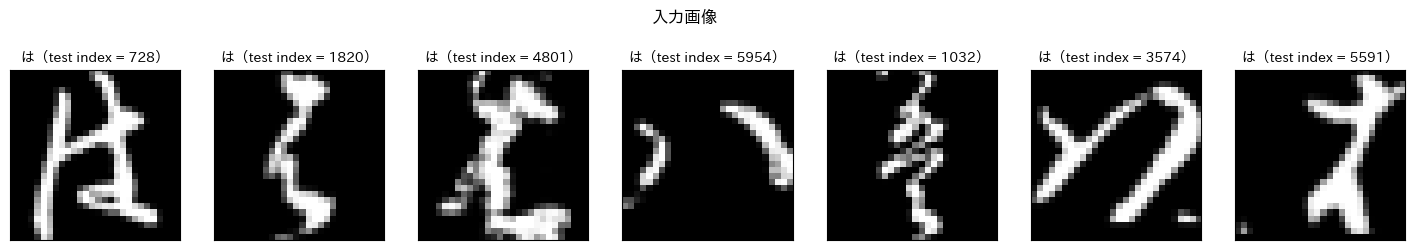

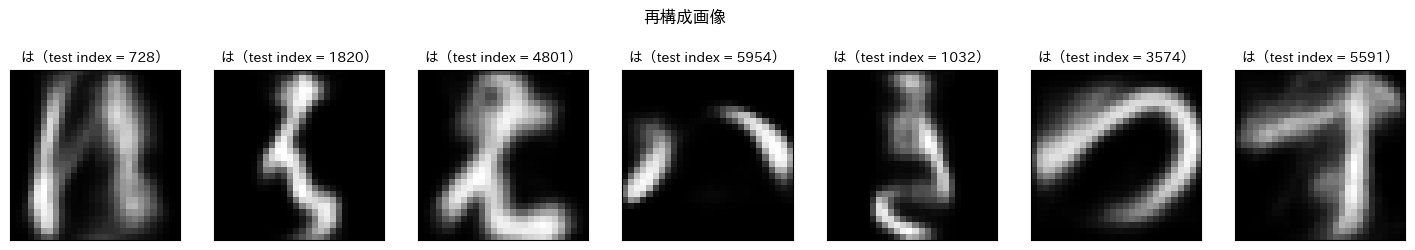

In [16]:
# テストデータ散布図で離れた場所に位置する「は」データを見てみる
# 　　※一部の集団は埋もれている，散布図の凡例をクリックすると凡例毎に絞り込める．
# test_data index = 728：原点（0,0）のやや左下にある「は」集団の「は」データ
# test_data index = 1820：原点（0,0）付近から右へ広がる「は」集団の「は」データ
# test_data index = 4801：原点（0,0）付近から右下へ広がる「は」集団の「は」データ
# test_data index = 5954：原点（0,0）付近から左上へ広がる「は」集団の「は」データ

# test_data index = 1032：原点（0,0）付近から右上へ広がる「き」集団の中に混ざる「は」データ
# test_data index = 3574：原点（0,0）付近から左へ広がる「つ」集団の中に混ざる「は」データ
# test_data index = 5591：原点（0,0）付近から右上へ広がる「す」集団の中に混ざる「は」データ


test_index_list = [728, 1820, 4801, 5954, 1032, 3574, 5591]

display(df.iloc[test_index_list,:].T)

fig = plt.figure(figsize=(18,3))

for i in range(len(test_index_list)):
    ax = fig.add_subplot(1, len(test_index_list), i+1, xticks=[], yticks=[])
    ax.imshow(tf.reshape(test_images[test_index_list[i],:], (28,28) ), cmap='gray')
    ax.set_title(test_labels[test_index_list[i]])
    ax.set_title(f"{label_num_to_label_name[test_labels[test_index_list[i]]]}（test index = {test_index_list[i]}）", fontsize=10)
plt.suptitle("入力画像", fontsize=12)
plt.show()

fig = plt.figure(figsize=(18,3))
generate_images = model_ae(test_images[test_index_list,:])
for i in range(len(test_index_list)):
    ax = fig.add_subplot(1, len(test_index_list), i+1, xticks=[], yticks=[])
    ax.imshow(tf.reshape(generate_images[i,:], (28,28) ), cmap='gray')
    ax.set_title(f"{label_num_to_label_name[test_labels[test_index_list[i]]]}（test index = {test_index_list[i]}）", fontsize=10)
plt.suptitle("再構成画像", fontsize=12)
plt.show()



 AE モデルは 特徴抽出器 として利用することで，異常検知（異常値検出・外れ値検出）などに応用することが出来ます．


# VAEによるKMNISTの画像生成

AEは入力データを忠実に再現しようとしますが，そのために「入力データに似た存在しないデータを新たに生成する」ことが出来ません．


VAE（Variational Autoencoder）では，入力データを圧縮して得られる潜在変数を確率変数として表します．さらに，潜在変数を正規分布からサンプリングすることで，潜在空間上の分布に連続性を持たせることが出来ます．

計算手順としては次の通りです：

1. Encoderモデルにより，データ$x$から潜在変数$z$の分布の平均$\mu$と分散$\sigma^2$を出力<br>
2. 出力された平均$\mu$と分散$\sigma^2$の正規分布に従う潜在変数$z$をサンプリング<br>
3. Decoderモデルにより，潜在変数$z$から新たなデータ$\hat{x}$を生成<br>
4. 再構成損失とKullback–Leibler情報量（Kullback–Leibler divergence：大まかには2つの確率分布間の距離を表す指標）を足した損失関数で損失を算出

$$
\text{reconstruction loss} = \frac{1}{N}\sum^{N}_{i=1} \sum^{M}_{j=1}\{{-x_{ij}\log{(y_{ij})}-(1-x_{ij})\log(1-y_{ij})}\}
$$

$$
\text{KL divergence} =  - \frac{1}{2N}\sum^{N}_{i=1} \sum^{D}_{d=1}{(1+\log\sigma^2_{id}-\mu^2_{id}-\sigma^2_{id})}
$$
$$
\rm{loss} = \rm{reconstruction~loss} + \rm{KL~divergence}
$$


この時，
* $M$は，1枚の画像を平坦化した1次元ベクトルの要素数
 - 今回は，28ピクセル×28ピクセル = 784個
* $N$は，バッチサイズ
 - 今回は batch_size = 128，つまり128枚単位でデータを処理する
* $x_{ij}$は，各バッチにおける入力データの各要素
* $y_{ij}$は，各バッチにおける生成データの各要素
* $D$は，潜在変数の次元数
 - 今回は n_z = 2 とする．

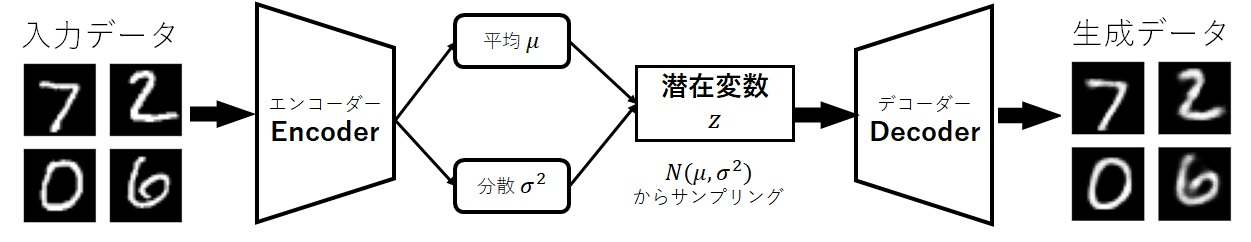

---
<small>
VAEで潜在変数$z$の分布の平均$\mu$と分散$\sigma$を算出する際，平均と分散はNNから出力されるため，負値も出力されうる．<br>
しかし，分散が負値となった場合，損失計算などができなくなるため，分散を正の値で出力させるようにsoftplus関数を使用する．<br>
</small>

## VAEモデルの構築

In [17]:
# バッチサイズを決める
batch_size = 128
# 潜在変数の次元数を決める
n_z = 2

# 潜在変数をサンプリングするための関数
def z_sampling(args):
    # 潜在変数の平均値と分散
    mean, var = args
    #平均0,標準偏差1の乱数を発生
    epsilon = tf.random.normal(shape=tf.keras.backend.shape(var), mean=0, stddev=1)
    return mean + var * epsilon


input_dim = train_images.shape[1]
output_dim = train_images.shape[1]

x = tf.keras.Input(shape=[input_dim])

encoder1 = tf.keras.layers.Dense(units=512, activation='relu')(x)
encoder2 = tf.keras.layers.Dense(units=64, activation='relu')(encoder1)
encoder3 = tf.keras.layers.Dense(units=32, activation='relu')(encoder2)
encoder4 = tf.keras.layers.Dense(units=10, activation='linear')(encoder3)

mean =  tf.keras.layers.Dense(units=2, activation='linear')(encoder4)
var = tf.keras.layers.Dense(units=2, activation='softplus')(encoder4)

z = tf.keras.layers.Lambda(z_sampling, output_shape=(n_z,))([mean, var])

#（decoder1_layerを後で画像生成器として使用する）
decoder1_layer = tf.keras.layers.Dense(units=32, activation='relu')
decoder1 = decoder1_layer(z)

#（decoder2_layerを後で画像生成器として使用する）
decoder2_layer = tf.keras.layers.Dense(units=64, activation='relu')
decoder2 = decoder2_layer(decoder1)

#（decoder3_layerを後で画像生成器として使用する）
decoder3_layer = tf.keras.layers.Dense(units=512, activation='relu')
decoder3 = decoder3_layer(decoder2)

#（decoder4_layerを後で画像生成器として使用する）
decoder4_layer = tf.keras.layers.Dense(units=output_dim, activation='sigmoid')
decoder4 = decoder4_layer(decoder3)

y = decoder4

# 損失関数の定義
class VAELossLayer(tf.keras.layers.Layer):
    def __init__(self, batch_size, **kwargs):
        super().__init__(**kwargs)
        self.batch_size = batch_size

    def call(self, inputs):
        x, y, mean, var = inputs

        # 再構成損失
        rec_loss = tf.reduce_mean(
            tf.reduce_sum(
                - x * tf.math.log(y + 1e-6)
                - (1 - x) * tf.math.log(1 - y + 1e-6),
                axis=-1
            )
        )
        # KLダイバージェンス損失
        kl_loss = -0.5 / self.batch_size * tf.reduce_sum(
            1 + tf.math.log(var**2 + 1e-6) - mean**2 - var**2,
            axis=1
        )
        self.add_loss(rec_loss + kl_loss)
        return y

y = VAELossLayer(batch_size, name="vae_loss")([x, y, mean, var])


# VAEのモデルを生成
model_vae = tf.keras.Model(inputs = x, outputs = y, name = 'model_vae')

model_vae.compile(optimizer="Adam")

model_vae.summary()

Model: "model_vae"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 512)       │    401,920 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │     32,832 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 32)        │      2,080 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 10)        │        330 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 2)         │         22 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 2)         │         22 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 2)         │          0 │ dense_12[0][0],   │
│                     │                   │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 32)        │         96 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 64)        │      2,112 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 512)       │     33,280 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 784)       │    402,192 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_loss            │ (None, 784)       │          0 │ input_layer_2[0]… │
│ (VAELossLayer)      │                   │            │ dense_17[0][0],   │
│                     │                   │            │ dense_12[0][0],   │
│                     │                   │            │ dense_13[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 874,886 (3.34 MB)

 Trainable params: 874,886 (3.34 MB)

 Non-trainable params: 0 (0.00 B)

### 未訓練状態におけるモデルの出力を確認する

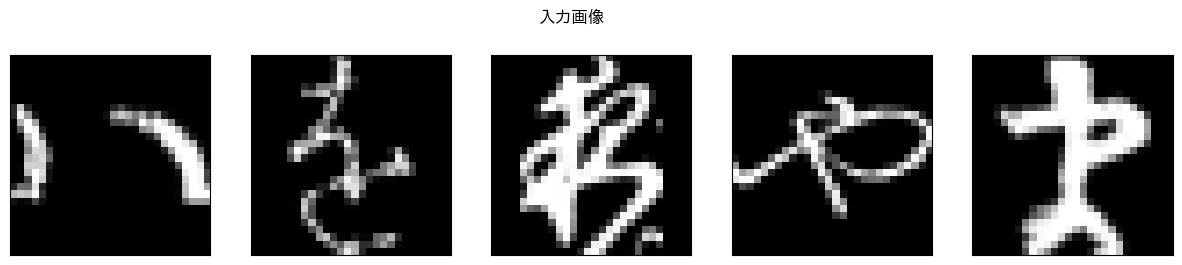

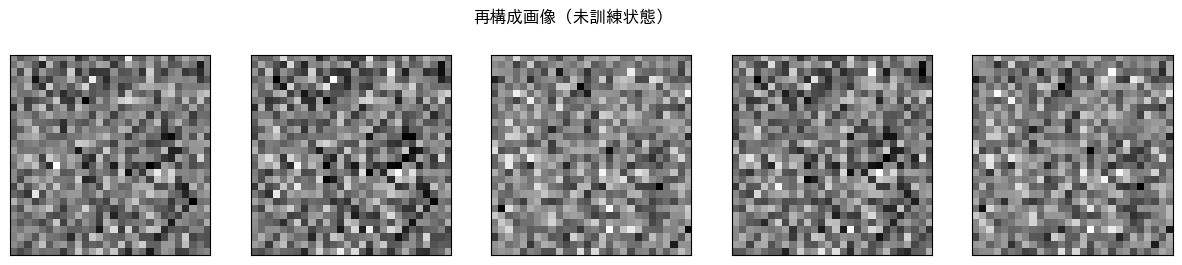

In [18]:

fig = plt.figure(figsize=(15,3))
for i in range(5):
    ax = fig.add_subplot(1, 5, i+1, xticks=[], yticks=[])
    ax.imshow(tf.reshape(test_images[i,:], (28,28) ), cmap='gray')
plt.suptitle("入力画像", fontsize=12)
plt.show()

fig = plt.figure(figsize=(15,3))
generate_images = model_vae(test_images[:5,:])
for i in range(5):
    ax = fig.add_subplot(1, 5, i+1, xticks=[], yticks=[])
    ax.imshow(tf.reshape(generate_images[i,:], (28,28) ), cmap='gray')
plt.suptitle("再構成画像（未訓練状態）", fontsize=12)
plt.show()

## モデルの訓練

Epoch 1/30
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 42948.9582

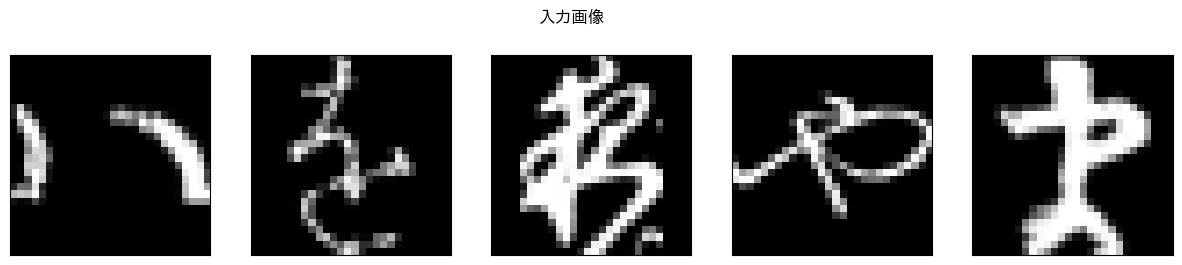

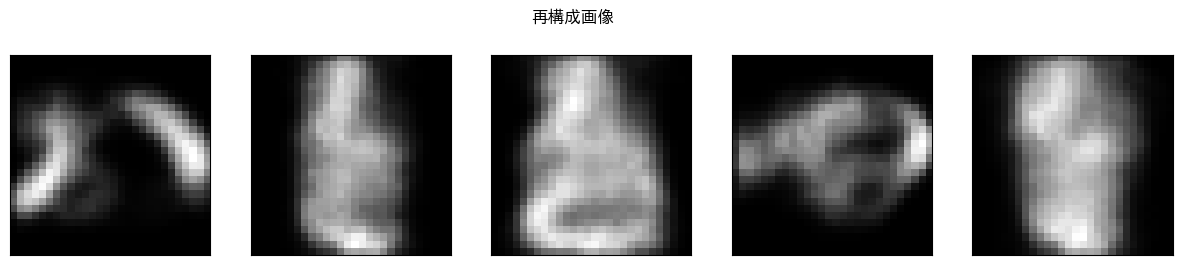

469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 38827.3906 - val_loss: 36493.5664
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 35514.7773 - val_loss: 35615.7656
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 34556.8828 - val_loss: 35285.0586
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 33931.4141 - val_loss: 35003.7461
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 33473.9648 - val_loss: 34673.5508
Epoch 6/30
462/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 33332.3317

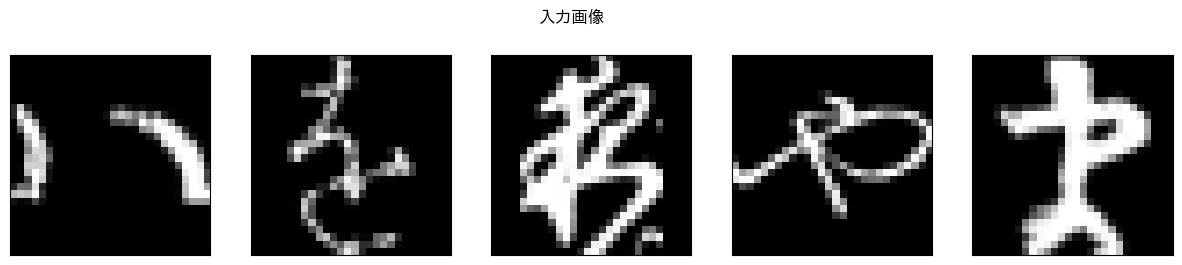

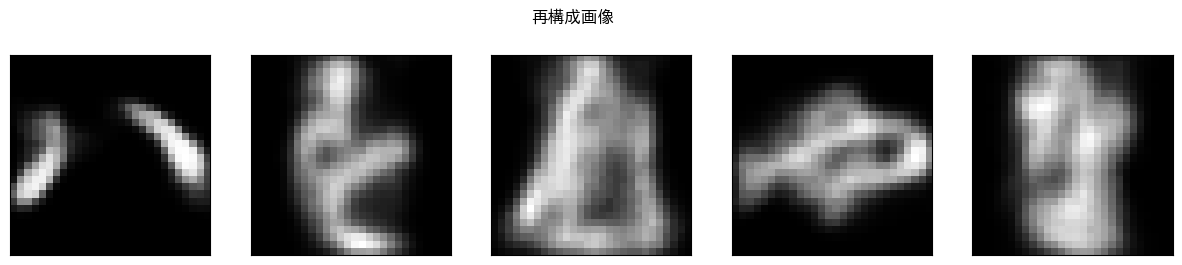

469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 33120.3633 - val_loss: 34486.0977
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 32826.3594 - val_loss: 34327.1133
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 32635.4277 - val_loss: 34198.8125
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 32461.9824 - val_loss: 34028.3359
Epoch 10/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 32272.1992 - val_loss: 34032.4688
Epoch 11/30
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 32328.1814

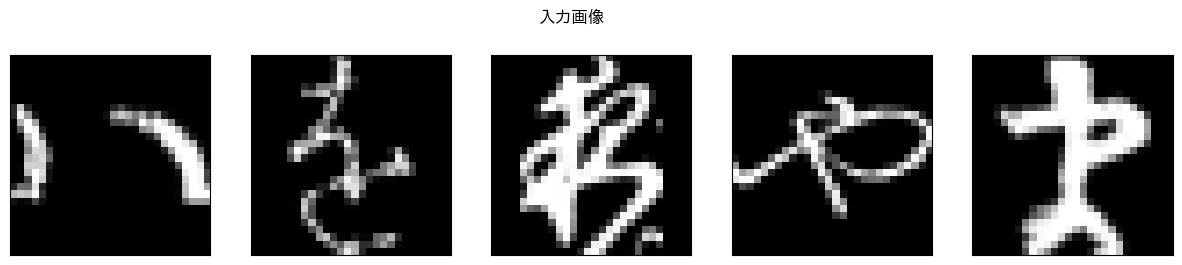

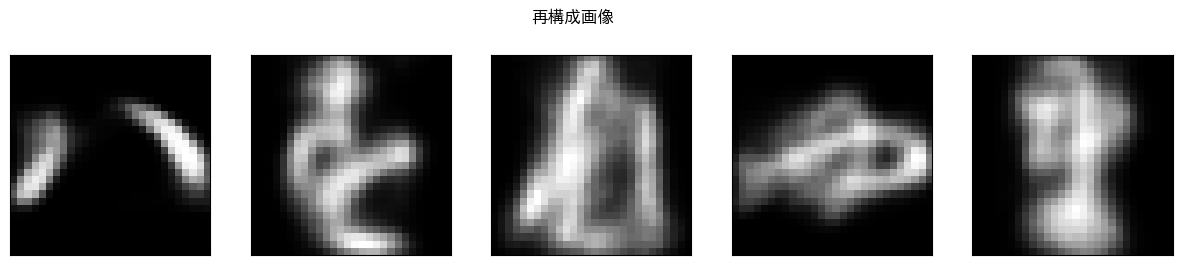

469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 32160.6094 - val_loss: 33839.4766
Epoch 12/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 32014.8828 - val_loss: 33720.9102
Epoch 13/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 31890.4648 - val_loss: 33645.9922
Epoch 14/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 31778.2168 - val_loss: 33563.5664
Epoch 15/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 31758.3203 - val_loss: 33518.2539
Epoch 16/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 32140.7196

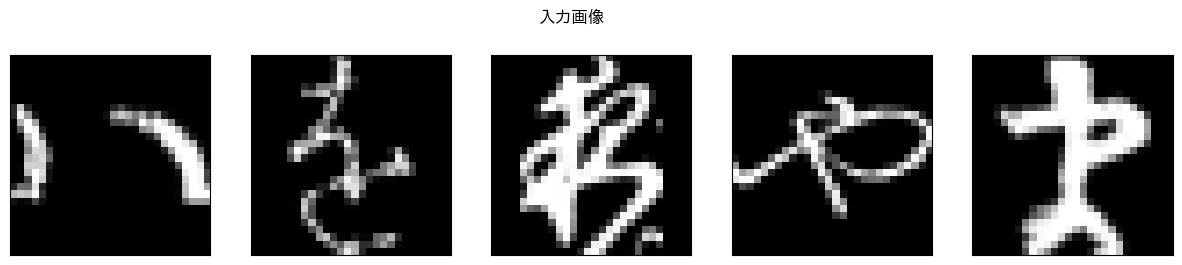

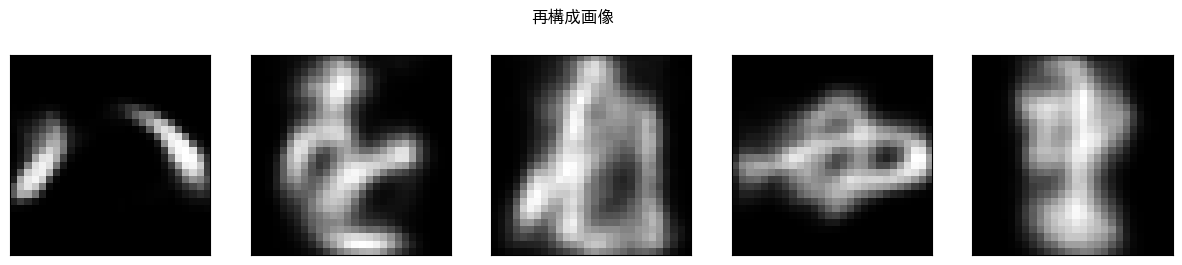

469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 31982.5508 - val_loss: 33579.3867
Epoch 17/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 31564.6934 - val_loss: 33418.2383
Epoch 18/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 31464.8750 - val_loss: 33473.8711
Epoch 19/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 31371.6621 - val_loss: 33424.8125
Epoch 20/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 31405.9102 - val_loss: 33311.0820
Epoch 21/30
463/469 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 31432.6067

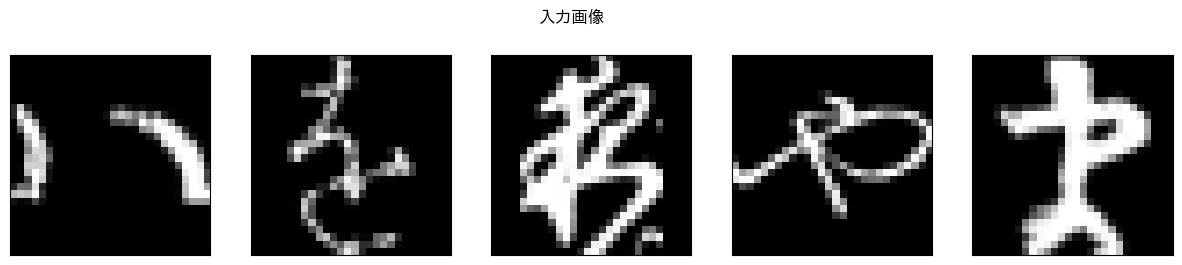

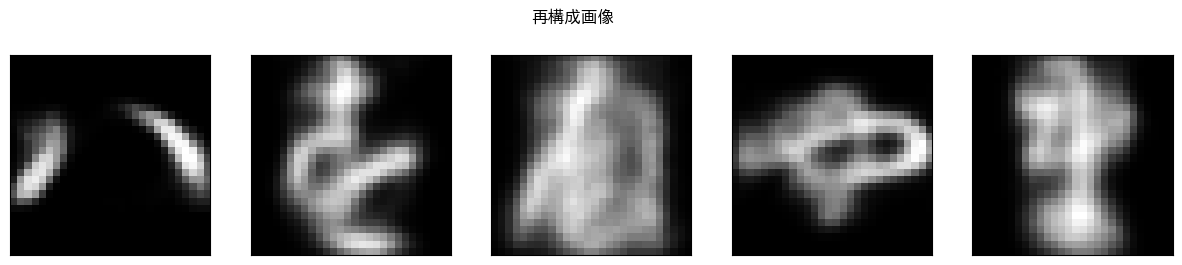

469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 31295.9863 - val_loss: 33214.6602
Epoch 22/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 31237.4434 - val_loss: 33241.3008
Epoch 23/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 31182.7012 - val_loss: 33204.1055
Epoch 24/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 31188.1855 - val_loss: 33333.9688
Epoch 25/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 31069.8242 - val_loss: 33128.9648
Epoch 26/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 31170.5736

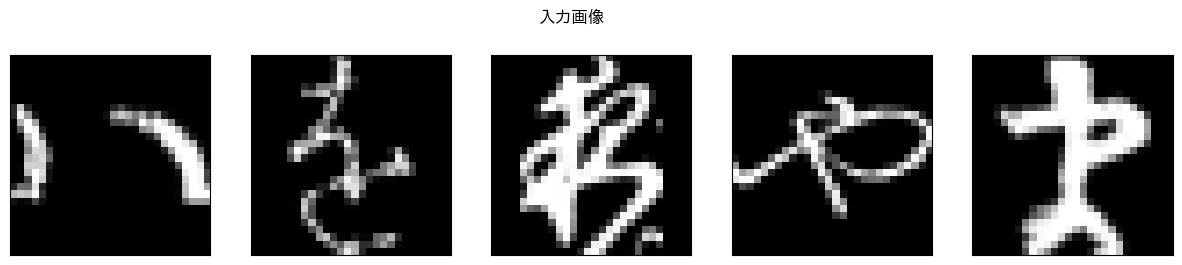

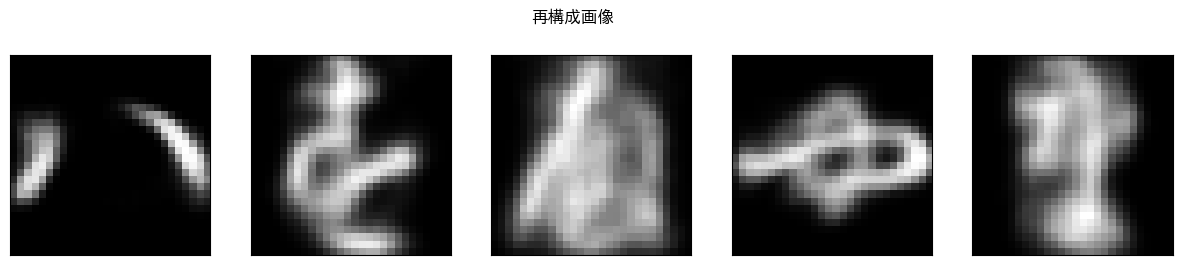

469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 31043.1660 - val_loss: 33184.2422
Epoch 27/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 30943.7461 - val_loss: 33052.9141
Epoch 28/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 30978.7090 - val_loss: 33201.6758
Epoch 29/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 30980.3828 - val_loss: 33242.3320
Epoch 30/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 30928.2305 - val_loss: 33352.2031


In [19]:
# 実行時間 約2～3分

class DisplayCallback(tf.keras.callbacks.Callback):

    def __init__(self, test_images):
        super().__init__()
        self.test_images = test_images

    def on_epoch_end(self, epoch, logs):
        # 5 Epoch毎に推論画像を出力する
        if (epoch % 5 == 0) :
            fig = plt.figure(figsize=(15,3))
            for i in range(5):
                ax = fig.add_subplot(1, 5, i+1, xticks=[], yticks=[])
                ax.imshow(tf.reshape(self.test_images[i,:], (28,28) ), cmap='gray')
            plt.suptitle("入力画像", fontsize=12)
            plt.show()
            fig = plt.figure(figsize=(15,3))
            generate_images = model_vae(self.test_images[:5,:])
            for i in range(5):
                ax = fig.add_subplot(1, 5, i+1, xticks=[], yticks=[])
                ax.imshow(tf.reshape(generate_images[i,:], (28,28) ), cmap='gray')
            plt.suptitle("再構成画像", fontsize=12)
            plt.show()



# 訓練中のログファイルを作成する準備
callbacks = []
callbacks.append(tf.keras.callbacks.CSVLogger('vae_training_log.csv'))
callbacks.append(DisplayCallback(test_images))

history = model_vae.fit(x = train_images,
                        # 正解ラベルの情報はモデルへ入れない
                        y = None,
                        shuffle = True,
                        epochs = 30,
                        batch_size = batch_size,
                        verbose = 1,
                        # 正解ラベルの情報はモデルへ入れない
                        validation_data = (test_images, None),
                        callbacks = callbacks
                        )

#### 損失関数の推移

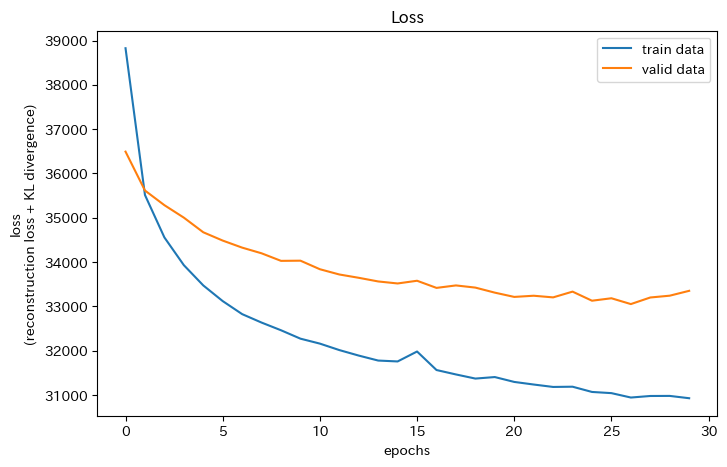

In [20]:
log_df = pd.read_csv('vae_training_log.csv')

epochs = log_df["epoch"].values
train_loss = log_df["loss"].values
valid_loss = log_df["val_loss"].values

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(epochs, train_loss, label="train data")
ax.plot(epochs, valid_loss, label="valid data")
ax.set_xlabel("epochs")
ax.set_ylabel("loss\n(reconstruction loss + KL divergence)")
ax.legend(loc="upper right")
ax.set_title("Loss")

plt.show()

## 元画像と復元画像の比較

テスト用データの画像を入力とし，VAEで再構成した画像と比較します．

まずはKMNISTデータセットのテスト用データの画像を表示します．

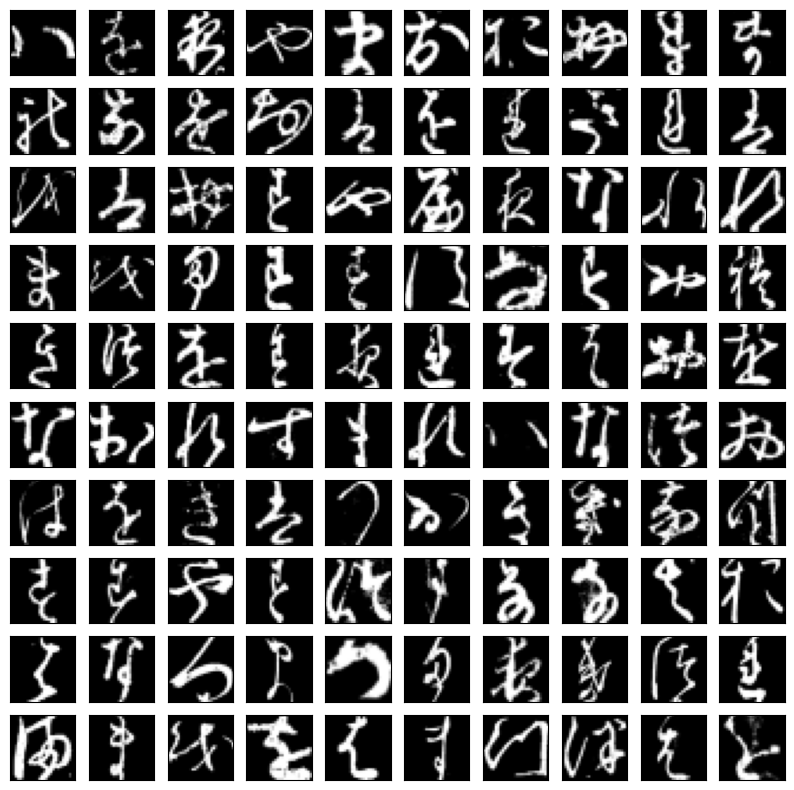

In [21]:
# KMNIST画像
fig = plt.figure(figsize=(10, 10))
for i in range(100):
    x = test_images[i].reshape(28,28)
    im = x
    ax = fig.add_subplot(10, 10, i+1, xticks=[], yticks=[])
    ax.imshow(im, 'gray')

次に，VAEで再構成した画像を表示します．

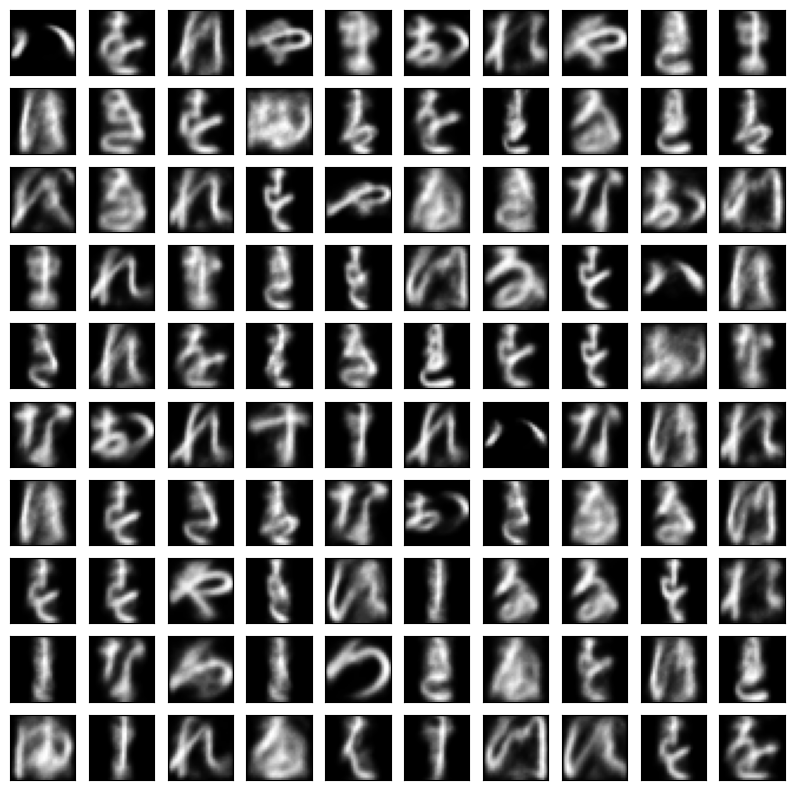

In [22]:
# VAEで再構成したKMNIST画像
fig = plt.figure(figsize=(10, 10))

for i in range(100):
    x = test_images[i]
    x = tf.reshape(x,(-1,28*28))
    y = model_vae(x)
    im = tf.reshape(y,(28,28))
    ax = fig.add_subplot(10, 10, i+1, xticks=[], yticks=[])
    ax.imshow(im, 'gray')

上の画像は，入力データからVAEで再構成をしたものです．

ここで，潜在変数からランダムにサンプリングをして新たな画像を生成すると，以下のようになります．

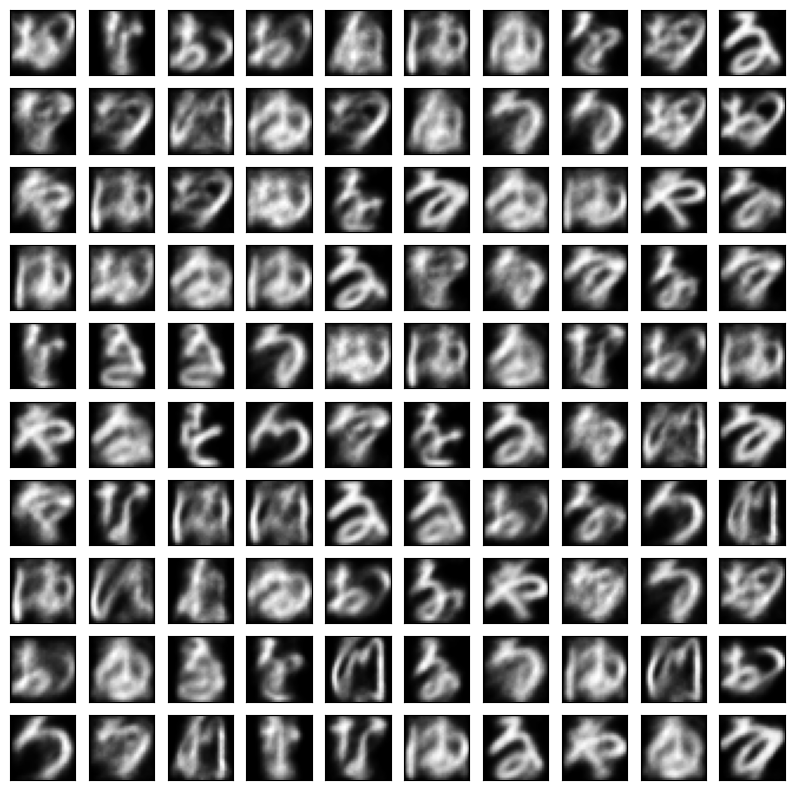

In [23]:
# 潜在変数からランダムサンプリング(潜在変数をランダムに決め, その潜在変数から生成されるKMNIST画像)

# 実行時間：約20～30秒

# 画像の生成器を定義する
input_decoder = tf.keras.layers.Input(shape=(n_z,))
h_decoder = decoder1_layer(input_decoder)
h_decoder = decoder2_layer(h_decoder)
h_decoder = decoder3_layer(h_decoder)
y = decoder4_layer(h_decoder)
generator = tf.keras.Model(input_decoder, y)

fig = plt.figure(figsize=(10, 10))

for i in range(100):
    # 潜在変数をランダムに決定する
    z = tf.random.normal([1, n_z])
    # ランダムに決定した潜在変数をデコーダへ入力し，推論（生成）する．
    y = generator.predict(z, verbose=0)

    im = tf.reshape(y,(28,28))
    ax = fig.add_subplot(10, 10, i+1, xticks=[], yticks=[])
    ax.imshow(im, 'gray')

各文字の中間のような画像も生成されるでしょう．

最後に，潜在変数による連続的な変化を可視化します．

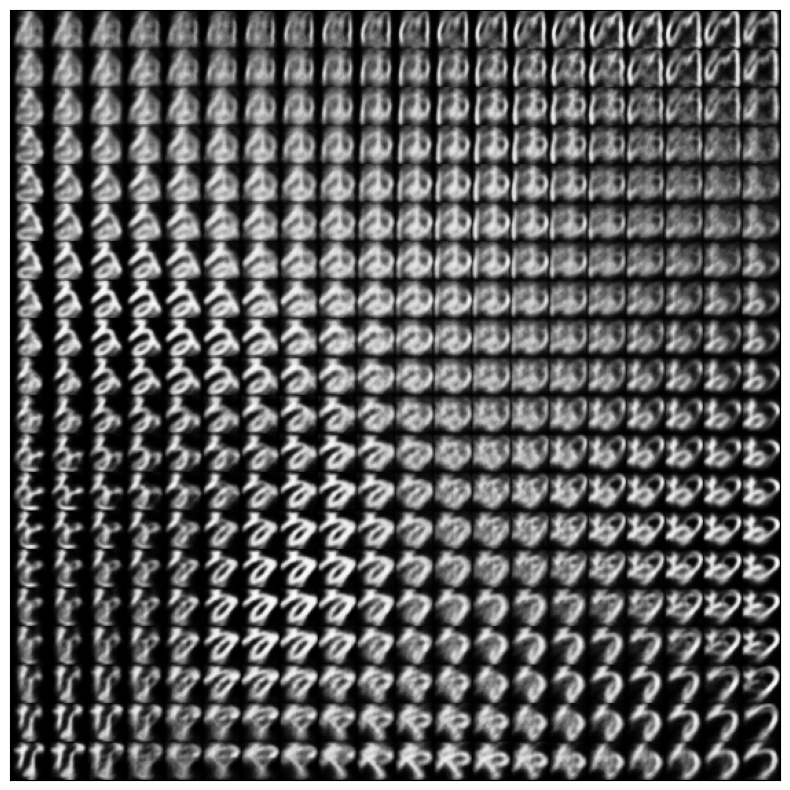

In [24]:
# 画像の生成器を定義する（前セルと同じ）
#input_decoder = tf.keras.layers.Input(shape=(n_z,))
#h_decoder = decoder1_layer(input_decoder)
#h_decoder = decoder2_layer(h_decoder)
#h_decoder = decoder3_layer(h_decoder)
#y = decoder4_layer(h_decoder)
#generator = tf.keras.Model(input_decoder, y)

# 実行時間：約25～40秒

n = 20
digit_size = 28
figure = np.zeros((digit_size*n, digit_size*n))

# 潜在変数
grid_x = scipy.stats.norm.ppf(np.linspace(0.05, 0.95, n))
grid_y = scipy.stats.norm.ppf(np.linspace(0.05, 0.95, n))

#  潜在変数を変化させて画像を生成する
for i, yi in enumerate(grid_x):
    for j, xi in enumerate(grid_y):
        decoded = generator.predict(np.array([[xi, yi]]), verbose=0)
        digit = decoded[0].reshape(digit_size, digit_size)
        figure[i*digit_size : (i+1)*digit_size, j*digit_size: (j+1)*digit_size] = digit


# 画像を可視化
plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap="Greys_r")
plt.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)
plt.show()

連続的な変化を可視化することで，各文字の「中間」の画像が新たに生成されている様子を見ることができるでしょう．